In [ ]:
!git clone https://github.com/gitdevqiang/SenWave.git

In [1]:
import os
import pandas as pd
import numpy as np
import torch
#torchvision, torchaudio installed
from tqdm import tqdm

In [2]:
print(torch.__version__)
print(torch.backends.mps.is_available())
print(torch.backends.mps.is_built()) #checks if your current PyTorch installation was compiled with support for the MPS backend

device = torch.device("mps" if torch.mps.is_available() else "cpu")
print(f"Using device: {device}")
torch.mps.empty_cache()

2.10.0
True
True
Using device: mps


In [3]:
import warnings
import nltk
SEED = 0
torch.manual_seed(SEED)
torch.mps.manual_seed(SEED)
torch.use_deterministic_algorithms(True)
warnings.filterwarnings('ignore')
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/jessie_guo/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [70]:
#customised

import numpy as np
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, DistilBertModel # Changed to DistilBertModel
from sklearn.model_selection import train_test_split
import torch.nn as nn
import pandas as pd # Import pandas here for df.read_csv
import os # Import os for os.makedirs
from sklearn.metrics import f1_score # Added for F1 score calculation

MAX_LEN       = 200
EPOCHS        = 4
LEARNING_RATE = 2e-05
TRAIN_BATCH_SIZE = 16
VALID_BATCH_SIZE = 16

LABEL_COLS = ['Optimistic', 'Thankful', 'Empathetic', 'Pessimistic',
              'Anxious', 'Sad', 'Annoyed', 'Denial', 'Official report', 'Joking']
classes = LABEL_COLS

# ── 模型定义 ──────────────────────────────────────────────
class DistilBERTCustom(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.distilbert = DistilBertModel.from_pretrained('distilbert-base-uncased') # Changed to DistilBertModel
        self.dropout = nn.Dropout(0.3)
        self.fc      = nn.Linear(self.distilbert.config.hidden_size, num_classes) # Use hidden_size from model config

    def forward(self, input_ids, attention_mask):
        outputs      = self.distilbert(input_ids=input_ids, attention_mask=attention_mask)
        # Extract the [CLS] token's embedding (first token) for pooling
        pooled       = outputs.last_hidden_state[:, 0, :] # Shape (batch_size, hidden_size)
        pooled       = self.dropout(pooled)
        return self.fc(pooled)

# ── Dataset 定义 ──────────────────────────────────────────
tokenizer = AutoTokenizer.from_pretrained('distilbert-base-uncased')

class CustomDataset(Dataset):
    def __init__(self, dataframe, tokenizer, max_len):
        self.tokenizer = tokenizer
        self.tweet     = dataframe['Tweet']
        self.targets   = dataframe['list'].tolist() # FIX: Convert Series to a list of lists
        self.max_len   = max_len

    def __len__(self):
        return len(self.tweet)

    def __getitem__(self, index):
        tweet  = " ".join(str(self.tweet[index]).split())
        inputs = self.tokenizer(
            tweet,
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids':      inputs['input_ids'].squeeze(0),
            'attention_mask': inputs['attention_mask'].squeeze(0),
            'targets':        torch.tensor(self.targets[index], dtype=torch.float)
        }

# ── 加载数据 ──────────────────────────────────────────────
df = pd.read_csv('SenWave/labeledtweets/labeledEn.csv')
print(f"Loaded {len(df)} rows, columns: {df.columns.tolist()}")

df['list'] = df[LABEL_COLS].values.tolist()
df = df[['Tweet', 'list']].dropna().reset_index(drop=True)

train_df, val_df = train_test_split(df, test_size=0.1, random_state=SEED)
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
print(f"Train: {len(train_df)}, Val: {len(val_df)}")

train_loader = DataLoader(CustomDataset(train_df, tokenizer, MAX_LEN),
                          batch_size=TRAIN_BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(CustomDataset(val_df,   tokenizer, MAX_LEN),
                          batch_size=VALID_BATCH_SIZE, shuffle=False)

# ── 训练 & 验证函数 ────────────────────────────────────────
model     = DistilBERTCustom(num_classes=10).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
criterion = nn.BCEWithLogitsLoss()

def train_epoch(model, loader):
    model.train()
    total_loss = 0
    for batch in loader:
        input_ids      = batch['input_ids'].to(device, dtype=torch.long)
        attention_mask = batch['attention_mask'].to(device, dtype=torch.long)
        targets        = batch['targets'].to(device)
        optimizer.zero_grad()
        loss = criterion(model(input_ids=input_ids, attention_mask=attention_mask), targets)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

def val_epoch(model, loader):
    model.eval()
    total_loss = 0
    all_logits = []
    all_targets = []
    with torch.no_grad():
        for batch in loader:
            input_ids      = batch['input_ids'].to(device, dtype=torch.long)
            attention_mask = batch['attention_mask'].to(device, dtype=torch.long)
            targets        = batch['targets'].to(device)
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            loss = criterion(outputs, targets)
            total_loss    += loss.item()
            
            all_logits.append(outputs.detach().cpu().numpy())
            all_targets.append(targets.detach().cpu().numpy())

    return total_loss / len(loader), np.concatenate(all_logits), np.concatenate(all_targets)

# ── 训练循环 ──────────────────────────────────────────────
for epoch in range(EPOCHS):
    train_loss = train_epoch(model, train_loader)
    val_loss, val_logits, val_targets = val_epoch(model, val_loader)
    
    # Calculate F1-weighted score
    probs = 1 / (1 + np.exp(-val_logits)) # Apply sigmoid to get probabilities
    predictions = (probs > 0.5).astype(int) # Use 0.5 as a default threshold
    f1_weighted = f1_score(val_targets, predictions, average='weighted', zero_division=0)

    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val F1 (weighted): {f1_weighted:.4f}")

# ── 保存模型 ──────────────────────────────────────────────
os.makedirs('models', exist_ok=True)
torch.save(model,              'Code_new/senwave-finetuned.pth')
torch.save(model.state_dict(), 'Code_new/senwave_weights_only.pth')
print("Saved: Code_new/senwave-finetuned.pth")
print("Saved: Code_new/senwave_weights_only.pth")

Loaded 10000 rows, columns: ['ID', 'Tweet', 'Optimistic', 'Thankful', 'Empathetic', 'Pessimistic', 'Anxious', 'Sad', 'Annoyed', 'Denial', 'Official report', 'Joking']
Train: 9000, Val: 1000


Loading weights: 100%|███████| 100/100 [00:00<00:00, 8960.46it/s]
DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch 1/4 | Train Loss: 0.3733 | Val Loss: 0.3189 | Val F1 (weighted): 0.4752
Epoch 2/4 | Train Loss: 0.3084 | Val Loss: 0.3095 | Val F1 (weighted): 0.5379
Epoch 3/4 | Train Loss: 0.2616 | Val Loss: 0.3165 | Val F1 (weighted): 0.5607
Epoch 4/4 | Train Loss: 0.2143 | Val Loss: 0.3277 | Val F1 (weighted): 0.5685
Saved: Code_new/senwave-finetuned.pth
Saved: Code_new/senwave_weights_only.pth


In [66]:
from datasets import load_dataset
import pandas as pd

df = pd.read_csv('SenWave/labeledtweets/labeledEn.csv')
df.head()
df.columns
lengths = [len(x) for x in df['Tweet']]
print(max(lengths))

140


In [64]:
label_cols = [
    "Optimistic",
    "Thankful",
    "Empathetic",
    "Pessimistic",
    "Anxious",
    "Sad",
    "Annoyed",
    "Denial",
    "Official report",
    "Joking"
]

text_col = "Tweet"

df = df[[text_col] + label_cols].copy() #concatenate columns
print(df)
df = df.dropna(subset = [text_col]) #remove rows that have missing values in text_col column
print(df)
df[label_cols] = df[label_cols].fillna(0).astype(int) #selects label_cols columns, replaces all missing values with 0, convert to integer
print(df[label_cols].sum())
df["labels"] = df[label_cols].values.tolist()
df = df.rename(columns = {text_col: "text"})
df = df[["text", "labels"]]
df.head()


                                                  Tweet  Optimistic  Thankful  \
0     A glass of wine keeps the corona away- DRAKE. ...           1         0   
1     Can Anyone tell me if you took the flu shot la...           0         0   
2     Btw producers send me beats Im working on musi...           1         0   
3     When someone you know.. apart of your family d...           0         0   
4     Dear soccer, I really miss you ,please come ba...           0         0   
...                                                 ...         ...       ...   
9995  One good thing about the quarantine: I can now...           1         0   
9996  Shoutout to for making the coronavirus testing...           1         1   
9997  I find it amazing that more people fear the Co...           0         0   
9998  thinking about how i put my two weeks in right...           1         0   
9999  Stop asking to change location manthat how you...           0         0   

      Empathetic  Pessimist

,text,labels
0,A glass of wine keeps the corona away- DRAKE. ...,"[1, 0, 0, 0, 0, 0, 0, 0, 0, 1]"
1,Can Anyone tell me if you took the flu shot la...,"[0, 0, 0, 0, 1, 0, 0, 0, 0, 0]"
2,Btw producers send me beats Im working on musi...,"[1, 0, 0, 0, 0, 0, 0, 0, 0, 1]"
3,When someone you know.. apart of your family d...,"[0, 0, 0, 0, 0, 1, 0, 0, 0, 0]"
4,"Dear soccer, I really miss you ,please come ba...","[0, 0, 0, 0, 0, 1, 1, 0, 0, 0]"


In [53]:
from datasets import Dataset, DatasetDict

dataset = Dataset.from_pandas(df)
split = dataset.train_test_split(test_size = 0.2, seed = 0)

senwave_dataset = DatasetDict({
    "train": split["train"],
    "validation": split["test"]
})
senwave_dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'labels'],
        num_rows: 8000
    })
    validation: Dataset({
        features: ['text', 'labels'],
        num_rows: 2000
    })
})

In [54]:
from transformers import AutoTokenizer, DataCollatorWithPadding

model_checkpoint = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

# Tokenize the text
def tokenize_labels(examples):
    tokenized = tokenizer(examples["text"], 
                         padding="max_length", 
                         truncation=True)
    return tokenized
    
tokenized_senwave = senwave_dataset.map(tokenize_labels, batched=True, remove_columns = ['text'])

tokenized_senwave.set_format(
    type = "torch",
    columns = ["input_ids", "attention_mask", "labels"])

print(pd.DataFrame(tokenized_senwave['train']))
print(type(tokenized_senwave["train"][0]["labels"])) #type of labels for first example

class CustomDataCollator:
    def __call__(self, batch):
        input_ids = torch.stack([x["input_ids"] for x in batch])
        attention_mask = torch.stack([x["attention_mask"] for x in batch])
        labels = torch.stack([x["labels"] for x in batch]).float()  #.to(torch.float32)
        return {"input_ids": input_ids,
                "attention_mask": attention_mask,
                "labels": labels}

data_collator = CustomDataCollator()

Map: 100%|█████████| 2000/2000 [00:00<00:00, 15275.90 examples/s]


                                                 labels  \
0     [tensor(1), tensor(0), tensor(0), tensor(0), t...   
1     [tensor(0), tensor(0), tensor(0), tensor(1), t...   
2     [tensor(0), tensor(0), tensor(0), tensor(0), t...   
3     [tensor(0), tensor(1), tensor(1), tensor(0), t...   
4     [tensor(0), tensor(0), tensor(0), tensor(0), t...   
...                                                 ...   
7995  [tensor(0), tensor(0), tensor(0), tensor(0), t...   
7996  [tensor(0), tensor(0), tensor(0), tensor(0), t...   
7997  [tensor(1), tensor(0), tensor(0), tensor(0), t...   
7998  [tensor(1), tensor(0), tensor(0), tensor(0), t...   
7999  [tensor(0), tensor(0), tensor(0), tensor(0), t...   

                                              input_ids  \
0     [tensor(101), tensor(2122), tensor(2420), tens...   
1     [tensor(101), tensor(2522), tensor(17258), ten...   
2     [tensor(101), tensor(2129), tensor(2515), tens...   
3     [tensor(101), tensor(2258), tensor(14876), ten...

In [65]:
import torch.nn as nn
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer, EarlyStoppingCallback

classes = label_cols
model_1 = AutoModelForSequenceClassification.from_pretrained(model_checkpoint, 
                                                             num_labels = len(classes), #len(ekman_classes), 
                                                             problem_type = "multi_label_classification") #load the weights in saved dtype. Without, doubles memory usage if weights originally torch.bfloat16
model_1.to(device)

from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, precision_recall_fscore_support

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    probs = 1 / (1 + np.exp(-logits))
    
    predictions = (probs > 0.3).astype(int)  # Get the predicted class labels
    precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(labels, predictions, average='weighted', zero_division=0)
    f1_micro = f1_score(labels, predictions, average = "micro", zero_division = 0)
    f1_macro = f1_score(labels, predictions, average = "macro", zero_division = 0)
    precision_micro = precision_score(labels, predictions, average="micro", zero_division=0),
    recall_micro = recall_score(labels, predictions, average="micro", zero_division=0),
    precision_macro = precision_score(labels, predictions, average="macro", zero_division=0),
    recall_macro = recall_score(labels, predictions, average="macro", zero_division=0),
    
    return {
        'f1_weighted': f1_weighted,
        'precision_weighted': precision_weighted,
        'recall_weighted': recall_weighted,
        'f1_micro': f1_micro,
        'precision_micro': precision_micro,
        'recall_micro': recall_micro,
        'f1_macro': f1_macro,
        'precision_macro': precision_macro,
        'recall_macro': recall_macro
    }
    
training_args = TrainingArguments(
    output_dir = "distilbert_finetuned-senwave",
    num_train_epochs = 20,
    per_device_train_batch_size = 16,
    gradient_accumulation_steps = 4, #accumulate gradients across several batches and update once as opposed to updating weights every batch, simulates training with large batch size w/o storing, saves memory but slower training
    #gradient_checkpointing=True, #recomputes intermediate activations during forward pass as opposed to storing - extra computation but saves memory
    fp16 = False, #bf16 for fast mixed precision training, fp16 false for mps
    learning_rate = 3e-5, #initial lr
    logging_steps = 100, #controls how frequently to update + return loss
    eval_strategy = "epoch", #when to evaluate a model during training
    save_strategy = "epoch", #when to save
    weight_decay = 0.01, #L2 regularisation, helps prevent model from overfitting by discouraging large weights - uses AdamW, independent of weight updates --> better training stability
    metric_for_best_model = 'eval_f1_weighted',
    greater_is_better = True,
    load_best_model_at_end = True,
    save_total_limit = 2
)

trainer = Trainer(
    model = model_1,
    args = training_args,
    train_dataset = tokenized_senwave["train"],
    eval_dataset = tokenized_senwave["validation"],
    processing_class = tokenizer,
    data_collator = data_collator,
    compute_metrics = compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
    #pos_weight = pos_weight
)

trainer.train()

trainer.save_model("distilbert_finetuned-senwave-final")
tokenizer.save_pretrained("distilbert_finetuned-senwave-final")

Loading weights: 100%|███████| 100/100 [00:00<00:00, 9255.88it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss


KeyboardInterrupt: 

In [ ]:
from sklearn.metrics import f1_score, precision_score, recall_score

def find_best_threshold(logits, labels):
    probs = 1/(1 + np.exp(-logits))
    best_t_micro = 0.5
    best_t_macro = 0.5
    best_t_weighted = 0.5
    best_f1_micro = 0
    best_f1_macro = 0
    best_f1_weighted = 0

    for t in np.arange(0.1, 0.9, 0.05):
        preds = (probs > t).astype(int)
        f1_micro = f1_score(labels, preds, average = "micro", zero_division = 0)
        f1_macro = f1_score(labels, preds, average = "macro", zero_division = 0)
        f1_weighted = f1_score(labels, preds, average = "weighted", zero_division = 0)
        if f1_micro > best_f1_micro:
            best_f1_micro = f1_micro
            best_t_micro = t
        if f1_macro > best_f1_macro:
            best_f1_macro = f1_macro
            best_t_macro = t
        if f1_weighted > best_f1_weighted:
            best_f1_weighted = f1_weighted
            best_t_weighted = t
            
    return best_t_macro, best_t_micro, best_t_weighted, best_f1_macro, best_f1_micro, best_f1_weighted

outputs = trainer.predict(tokenized_go_emotions["validation"])
logits = outputs.predictions
best_t_macro, best_t_micro, best_t_weighted, best_f1_macro, best_f1_micro, best_f1_weighted = find_best_threshold(logits, outputs.label_ids)
print(best_t_macro, best_t_micro, best_t_weighted, best_f1_macro, best_f1_micro, best_f1_weighted)

probs = 1 / (1 + np.exp(-logits))  # Sigmoid function
threshold = [0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5] 

for t in threshold:
    new_predictions = (probs > t).astype(int)
    f1_weighted = f1_score(outputs.label_ids, new_predictions, average='weighted')
    f1_micro = f1_score(outputs.label_ids, new_predictions, average='micro')
    f1_macro = f1_score(outputs.label_ids, new_predictions, average='macro')
    prec = precision_score(outputs.label_ids, new_predictions, average='weighted')
    rec = recall_score(outputs.label_ids, new_predictions, average='weighted')
    print(f"Threshold: {t}| F1_W: {f1_weighted:.3f} | F1_micro: {f1_micro:.3f} | F1_macro: {f1_macro:.3f} | P: {prec:.3f} | R: {rec:.3f}")
    

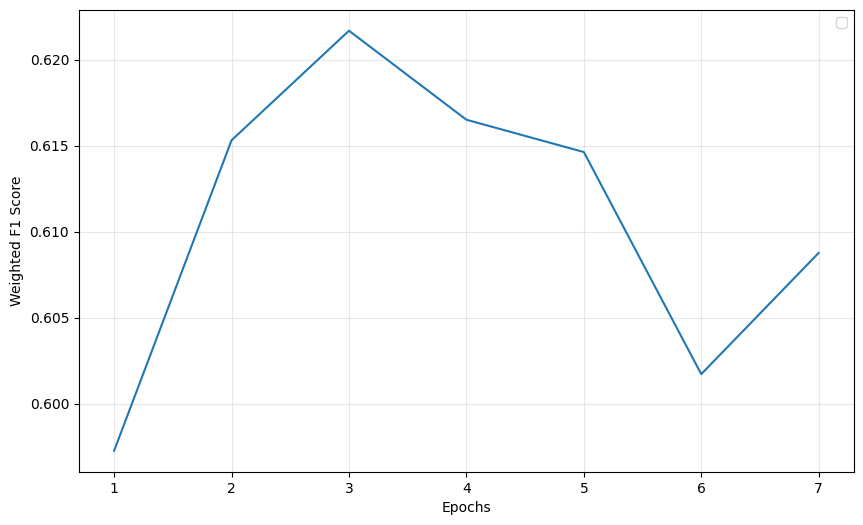

In [49]:
#Training and Validation Loss, Weighted_F1 Curves
import matplotlib.pyplot as plt
import pandas as pd

history = trainer.state.log_history
df = pd.DataFrame(history)

train_df = df[df['loss'].notna()]
eval_df = df[df['eval_loss'].notna()]
weighted_f1_df = df[df['eval_f1_weighted'].notna()]

plt.figure(figsize=(10, 6))

plt.plot(train_df['epoch'], train_df['loss'], label='Training Loss')
plt.plot(eval_df['epoch'], eval_df['eval_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("Training and Validation Loss")
plt.clf()

plt.plot(weighted_f1_df['epoch'], weighted_f1_df['eval_f1_weighted'])
plt.xlabel('Epochs')
plt.ylabel('Weighted F1 Score')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("Weighted F1 Score")


In [5]:
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer, EarlyStoppingCallback

model_new = AutoModelForSequenceClassification.from_pretrained("Code_new/senwave_weights_only.pth")
#tokenizer_new = AutoTokenizer.from_pretrained("distilbert_finetuned-goemotions-final")

model_new.to(device)
model_new.eval()

OSError: Code_new/senwave_weights_only.pth is not a local folder and is not a valid model identifier listed on 'https://huggingface.co/models'
If this is a private repository, make sure to pass a token having permission to this repo either by logging in with `hf auth login` or by passing `token=<your_token>`

In [181]:
from torch.utils.data import Dataset
class CustomDataset(Dataset):
    def __init__(self, dataframe, tokenizer, max_len):
        self.tokenizer = tokenizer
        self.dataframe = dataframe
        self.texts = dataframe['text']
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, index):
        text = str(self.texts.iloc[index])
        text = " ".join(text.split())
        inputs = self.tokenizer(
            text,
            None,
            add_special_tokens=True,  # Add special tokens
            max_length=self.max_len,
            padding='max_length',  # Pad to max_length
            return_token_type_ids=True,
            return_tensors='pt',  # Return PyTorch tensors
            truncation=True  # Truncate sequences longer than max_length
        )
        
        input_ids = inputs['input_ids'].squeeze(0)  # Remove the added batch dimension
        attention_mask = inputs['attention_mask'].squeeze(0)  # Remove the added batch dimension
        return {
            'input_ids': input_ids,
            'attention_mask': attention_mask,
        }

In [182]:
def test():
    model_new.eval()
    all_outputs = []
    with torch.no_grad():
        for data in test_loader:
            input_ids = data['input_ids'].to(device) #, dtype=torch.long)
            attention_mask = data['attention_mask'].to(device) #, dtype=torch.long)
            outputs = model_new(input_ids = input_ids, attention_mask = attention_mask)
            logits = outputs.logits
            probs = torch.sigmoid(logits)
            
            all_outputs.extend(probs.cpu().np().tolist())
    return all_outputs

In [226]:
texts_path = './Georgian Texts/Vazha Pshavela/'
sources = ['en/', 'ggl/', 'gem/', 'gem_ru/', 'gpt/', 'gpt_ru/']
poems_path = texts_path + 'Poems/revised/'
poem_names = []

ge_poems_directory = os.fsencode(poems_path + 'ge/')
for file in sorted(os.listdir(ge_poems_directory)):
    file = file.decode()
    if file.endswith(".md"):
        poem_names.append(file)

print(poem_names)

['01_i_believe_i_always_have_believed.md', '02_bakur.md', '03_some_day_it_will_happen_i_shall_die.md', '04_i_feel_like_singing_and_i_shall_sing.md', '05_voice_from_the_grave.md', '06_that_in_truth_is_not_manliness.md', '07_the_law_of_the_world_is_thus.md', '08_amiran.md', '09_the_old_song_of_cavaliers.md', '10_consciences_song.md', '11_as_once_you_did_o_lady_as_once_you_did.md', '12_loneliness.md', '13_what_created_me_a_human_being.md', '14_yet_again_shall_i_see_the_spring.md', '15_thrush_its_the_same_song_you_sing.md']


In [227]:
lengths = [len(tokenizer.encode(text)) for text in poem_df['text']]

print(np.percentile(lengths, [50, 75, 90, 95, 99]))

MAX_LEN = 64

[14.   16.75 17.   18.7  20.  ]


In [228]:
from torch.utils.data import DataLoader

for source in sources:
    for poem in poem_names:
        poem_text = [line.strip() for line in open(poems_path + source + poem, "r")]
        poem_df = pd.DataFrame(poem_text, columns=['text'])

        test_dataset = CustomDataset(poem_df, tokenizer, MAX_LEN)
        test_params = {'batch_size': 1, 'shuffle': False}
        test_loader = DataLoader(test_dataset, **test_params)
        
        test_outputs = np.array(test())

        test_outputs = (test_outputs >= 0.5).astype(int)
        for label in ekman_classes:
            poem_df[label] = 0

        for i in range(len(test_outputs)):
            for j, label in enumerate(ekman_classes):
                poem_df.at[i, label] = test_outputs[i][j]

        poem_df.to_csv('Code_new/results/poems/sentiment/' + source + poem)

In [229]:
def all_chapter_dataframe(source, ekman_classes):
    total_counts = {label: 0 for label in ekman_classes}
    
    for poem in poem_names:
        df = pd.read_csv('Code_new/results/poems/sentiment/' + source + poem)
        
        if 'text' in df.columns:
            df = df.drop(columns = ['text'])
        
        # sum counts directly (since labels are 0/1)  
        for label in ekman_classes:
            if label in df.columns:
                total_counts[label] += df[label].sum()

    new_df = pd.DataFrame({
        "Sentiment": list(total_counts.keys()),
        "Count": list(total_counts.values())
    })

    return new_df

  Sentiment  Count  Count  Count  Count  Count  Count
0     anger     14     23     17     15     19     19
1   disgust      0      1      0      0      0      0
2      fear      3     13      8     11      9      9
3       joy     48     42     41     40     42     48
4   sadness      3      3      3      4      3      6
5  surprise      7      9      9     10      5     11
6   neutral    170    165    171    160    169    157
  Sentiment  Hewitt  Google  Gemini  Gemini_ru  ChatGPT  ChatGPT_ru
0     anger      14      23      17         15       19          19
1   disgust       0       1       0          0        0           0
2      fear       3      13       8         11        9           9
3       joy      48      42      41         40       42          48
4   sadness       3       3       3          4        3           6
5  surprise       7       9       9         10        5          11
6   neutral     170     165     171        160      169         157
0     Models anger disgu

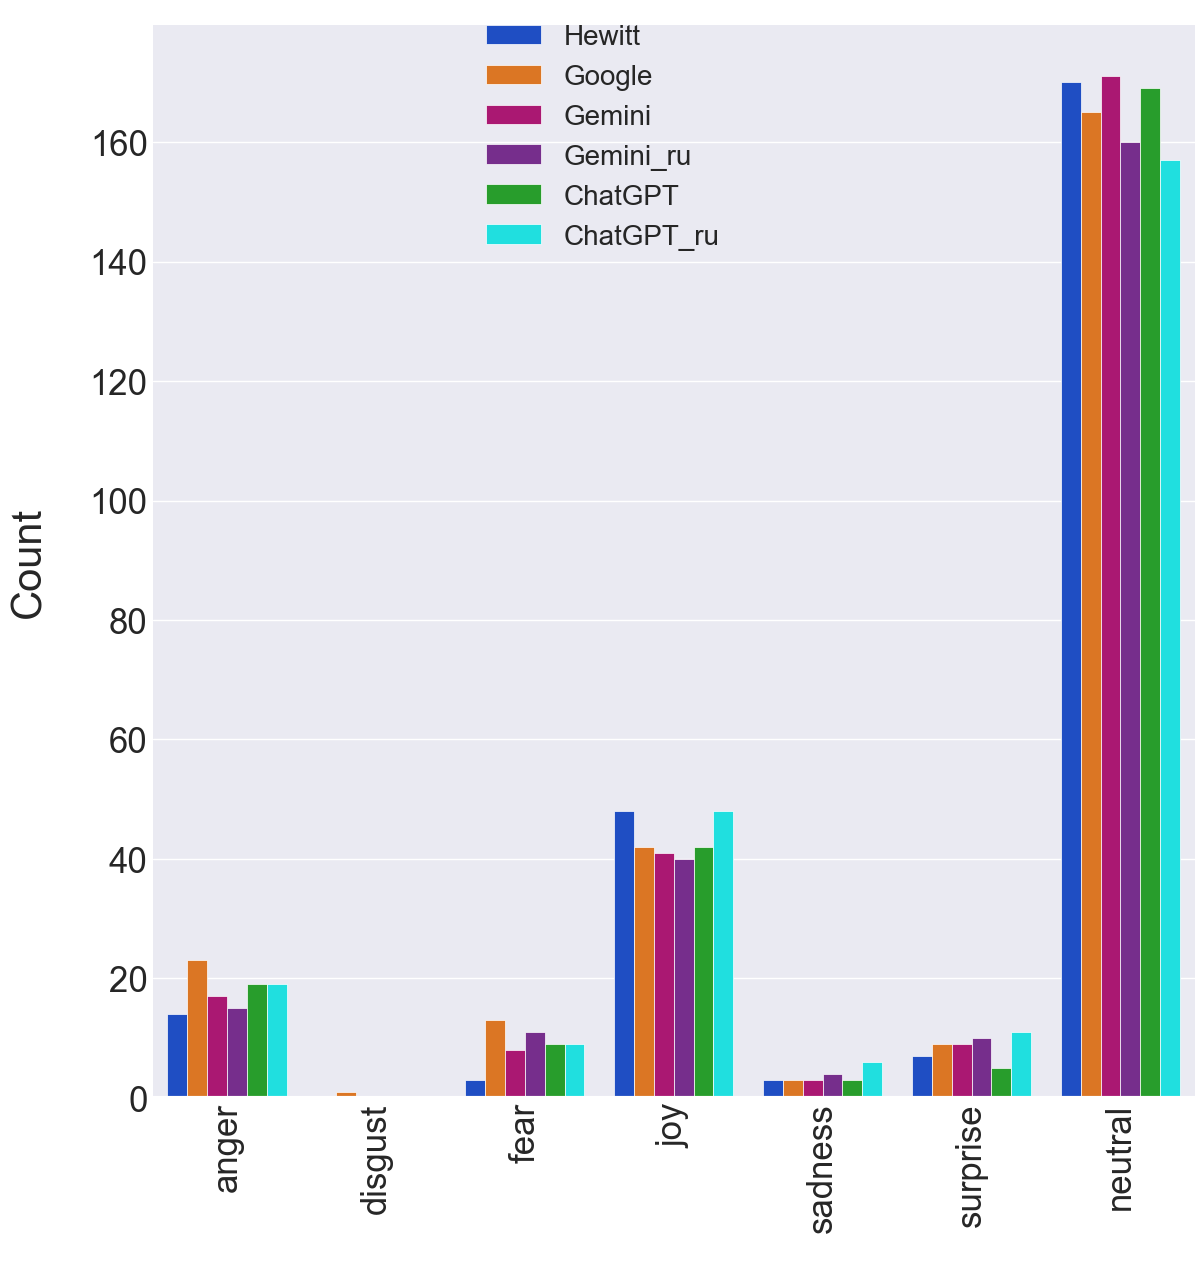

In [289]:
import seaborn as sns
import matplotlib.pyplot as plt

hewitt_sentiment = all_chapter_dataframe('en/', ekman_classes)
google_sentiment = all_chapter_dataframe('ggl/', ekman_classes)
gemini_sentiment = all_chapter_dataframe('gem/', ekman_classes)
gemini_ru_sentiment = all_chapter_dataframe('gem_ru/', ekman_classes)
chatgpt_sentiment = all_chapter_dataframe('gpt/', ekman_classes)
chatgpt_ru_sentiment = all_chapter_dataframe('gpt_ru/', ekman_classes)

df_new = pd.concat(
    [
        hewitt_sentiment, 
        google_sentiment['Count'], 
        gemini_sentiment['Count'], 
        gemini_ru_sentiment['Count'], 
        chatgpt_sentiment['Count'],
        chatgpt_ru_sentiment['Count']
    ],
    axis=1
)

print(df_new)

df_new.columns = ['Sentiment', 'Hewitt', 'Google', 'Gemini', 'Gemini_ru', 'ChatGPT', 'ChatGPT_ru']
print(df_new)

df_sentiment_counts = df_new.T.reset_index()
df_sentiment_counts.columns = df_sentiment_counts.iloc[0, ]
df_sentiment_counts = df_sentiment_counts.iloc[1:, ].reset_index(drop=True)
df_sentiment_counts = df_sentiment_counts.rename(columns={'Sentiment': 'Models'})

print(df_sentiment_counts.head())
print(df_sentiment_counts.columns)

df_new = pd.melt(df_new, id_vars="Sentiment", var_name="Models", value_name="Count")
print(df_new)
colors = ["blue", "orange", "magenta", "purple", "green", "cyan"]  
myPalette = sns.xkcd_palette(colors)

sns.set_style("darkgrid")
g = sns.catplot(x='Sentiment', y='Count', hue='Models', data=df_new, kind='bar', height=12, palette=myPalette, legend=True)
g.despine(left=True)
sns.move_legend(g, 'upper center', prop={"size": 20}, title='')
plt.ylabel('Count', labelpad=30, fontsize=30)
plt.xlabel(' ')
#plt.gca().yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}')) #{tick values, add commas for thousands operator, round to 0 decimal places}
plt.yticks(fontsize= 25)
plt.xticks(fontsize = 25)
plt.xticks(rotation=90)
plt.savefig('Code_new/results/poems/graphs/sentiment_all_ru.png')

In [231]:
sentiment_polarity = {
    'anger': -2,
    'disgust': -1,
    'fear': -2,
    'joy':  2,
    'sadness': -1,
    'surprise': 1,
    'neutral': 0,
}

In [232]:
%matplotlib inline
sns.set_style("whitegrid")
plt.style.use("fivethirtyeight")

In [237]:
def plot_polarity_vs_verse(poem, model_paths, model_labels, sentiment_polarity, output_path):
    plt.figure(figsize = (14, 6))

    for path, label in zip(model_paths, model_labels):
        df = pd.read_csv(path + poem)
        polarity_scores = []
        for _, row in df.iterrows():
            polarity = sum(
                row.get(emotion, 0) * weight for emotion, weight in sentiment_polarity.items()
            )
            polarity_scores.append(polarity)
            
        verses = np.arange(1, len(polarity_scores) + 1)
        
        plt.plot(verses, polarity_scores, label = label)

    plt.ylabel('Sentiment Polarity')#, labelpad=40, fontsize=30)
    plt.xlabel('Verse Number')#, labelpad=30, fontsize=30)
    plt.title(f'Polarity vs. Verse for {poem[:2]}')
    
    plt.legend(title = 'Models')
    plt.grid(True)
    plt.tight_layout()
    
    plt.show()
    plt.savefig(output_path)


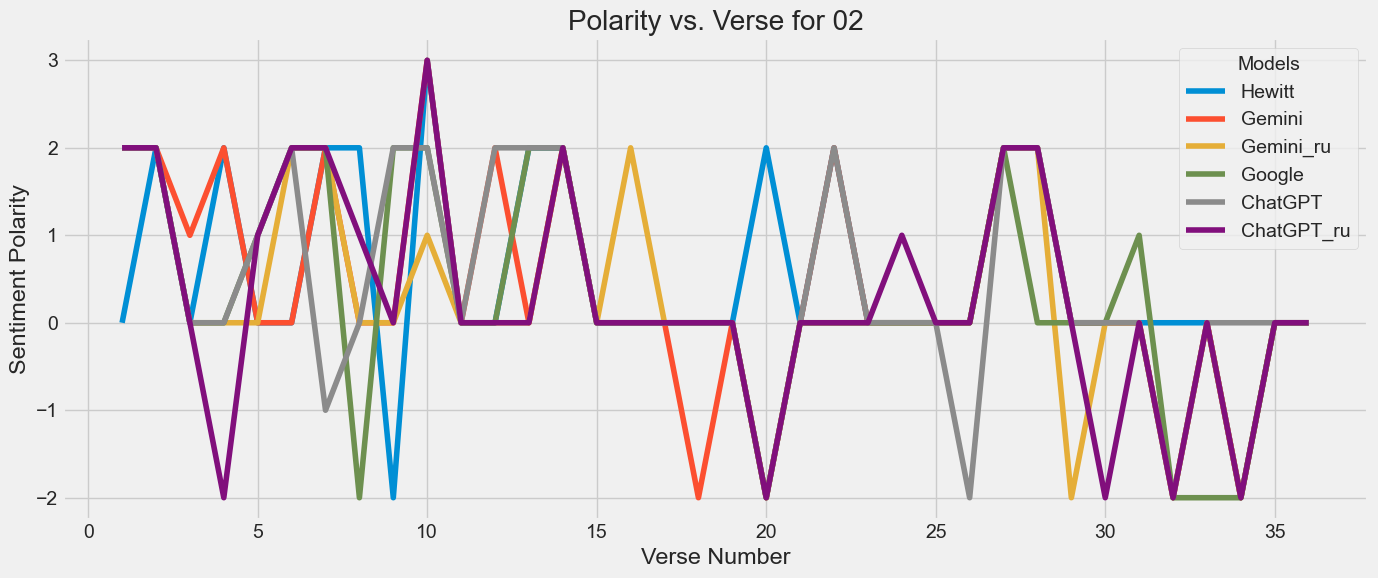

<Figure size 640x480 with 0 Axes>

In [238]:
poem = '02_bakur.md'

model_paths = [
    'Code_new/results/poems/sentiment/en/',
    'Code_new/results/poems/sentiment/gem/',
    'Code_new/results/poems/sentiment/gem_ru/',
    'Code_new/results/poems/sentiment/ggl/',
    'Code_new/results/poems/sentiment/gpt/',
    'Code_new/results/poems/sentiment/gpt_ru/'
]

model_labels = ['Hewitt', 'Gemini', 'Gemini_ru', 'Google', 'ChatGPT', 'ChatGPT_ru']
#plt.savefig('results/poems/graphs/hewitt_polarity.png')
plot_polarity_vs_verse(
    poem, model_paths, model_labels, sentiment_polarity, output_path = f'Code_new/results/poems/graphs/sentiment/{model_labels}_polarity.png'
)

In [241]:
topic_df = pd.read_csv('Code_new/results/poems/sentiment/' + 'gem/' + poem_names[0])
topic_df = topic_df.drop(['Unnamed: 0'], axis=1)

print(topic_df)

for poem in poem_names[1:]:
    df = pd.read_csv('Code_new/results/poems/sentiment/' + 'gem/' + poem)
    df = df.drop(['Unnamed: 0'], axis=1)
    topic_df = pd.concat([topic_df, df], axis=0)

print(topic_df)


                                                text  anger  disgust  fear  \
0  I believe, I've always believed In the eternal...      0        0     1   
1  I believe, even when the ashes Of a good heart...      0        0     1   
2  To suppress evil, to protect the good, It will...      0        0     1   
3  Nature does not kill a good heart, It carries ...      0        0     0   

   joy  sadness  surprise  neutral  
0    0        0         0        0  
1    0        0         0        0  
2    0        0         0        0  
3    0        0         0        1  
                                                 text  anger  disgust  fear  \
0   I believe, I've always believed In the eternal...      0        0     1   
1   I believe, even when the ashes Of a good heart...      0        0     1   
2   To suppress evil, to protect the good, It will...      0        0     1   
3   Nature does not kill a good heart, It carries ...      0        0     0   
0         – Tell us, Elizbara

In [247]:
import re
import gensim 
import nltk
from nltk.corpus import stopwords

stop_words = stopwords.words('english')
newStopWords = []
stop_words.extend(newStopWords)


def remove_stopwords(texts):
    return [[word for word in gensim.utils.simple_preprocess(str(text)) if word not in stop_words] for text in texts]
    #list without stopwords

def tokenize(texts):
    for text in texts:
        yield(gensim.utils.simple_preprocess(str(text), deacc=True))
        #tokenized, without punctuation, accents

def preprocessing(df):
    df = df.copy()
    df['text'] = df['text'].str.lower()                                                      # Convert to lowercase
    df['text'] = df['text'].str.replace(r'[^a-zA-Z#]', ' ', regex=True) #     # keep letters and spaces only
    df['text'] = df['text'].apply(lambda x:' '.join([w for w in x.split() if len(w)>2]))     # Remove short words
    df['tokens'] = list(tokenize(df['text']))
    df['tokens_no_stop'] = remove_stopwords(df['text'])
    df['tokens_no_stop_joined'] = df['tokens_no_stop'].apply(lambda x: ' '.join(x) )
    
    return df

def retrieve_text(df):
    doc = '. '.join(df['tokens_no_stop_joined'])
    return doc

def ngrams_series_func(data, n):
    wordList = re.sub("[^\w]", " ",  data).split() #replace non-words with spaces
    ngrams_series = (pd.Series(nltk.ngrams(wordList, n)).value_counts())[:5] #top 5 most frequent
    return ngrams_series

In [290]:
from matplotlib import cm
from matplotlib.ticker import FuncFormatter

cmap = sns.diverging_palette(0, 230, 90, 60, as_cmap=True)
barcolors = ['#87B88C','#9ED2A1','#E7E8CB','#48A0C9','#2A58A1','#2E8B55','#DF3659','Grey']
barstyle = {"edgecolor":"black", "linewidth": 1}

In [291]:
topic_df = preprocessing(topic_df)
topic_df.head()

,text,anger,disgust,fear,joy,sadness,surprise,neutral,tokens,tokens_no_stop,tokens_no_stop_joined
0,believe always believed the eternal life the s...,0,0,1,0,0,0,0,"[believe, always, believed, the, eternal, life...","[believe, always, believed, eternal, life, sou...",believe always believed eternal life soul good...
1,believe even when the ashes good heart are sca...,0,0,1,0,0,0,0,"[believe, even, when, the, ashes, good, heart,...","[believe, even, ashes, good, heart, scattered,...",believe even ashes good heart scattered wind w...
2,suppress evil protect the good will always gua...,0,0,1,0,0,0,0,"[suppress, evil, protect, the, good, will, alw...","[suppress, evil, protect, good, always, guardi...",suppress evil protect good always guardian poo...
3,nature does not kill good heart carries along ...,0,0,0,0,0,0,1,"[nature, does, not, kill, good, heart, carries...","[nature, kill, good, heart, carries, along, ti...",nature kill good heart carries along time imme...
0,tell elizbara what happened dawn,0,0,0,1,0,0,0,"[tell, elizbara, what, happened, dawn]","[tell, elizbara, happened, dawn]",tell elizbara happened dawn


In [295]:
text = retrieve_text(topic_df)
text.split('. ')

['believe always believed eternal life soul good lover country one pained country fate',
 'believe even ashes good heart scattered wind within one spark still ignites burning desire warmth',
 'suppress evil protect good always guardian poor troubled helper savior rescuer',
 'nature kill good heart carries along time immemorial',
 'tell elizbara happened dawn',
 'leks fall bakuri castle courtyard',
 'want stir old sorrows heart',
 'say men lament bakuri fate',
 'lives loved ones extinguished forever',
 'say man blame',
 'truth speak lie instead',
 'bear burden die soul clung life',
 'seen eyes bakuri battle fall',
 'heart aches alive fall enemy hands',
 'thoughts rise like poison throat',
 'want raise head straighten back',
 'run death take',
 'ashamed shameful',
 'know heard news afar',
 'one blamed thank god one spoke ill',
 'tell story battle',
 'great enemy army came surrounded like fence',
 'seven days fought guns killed many',
 'women making bullets deserve praise indeed',
 'eight

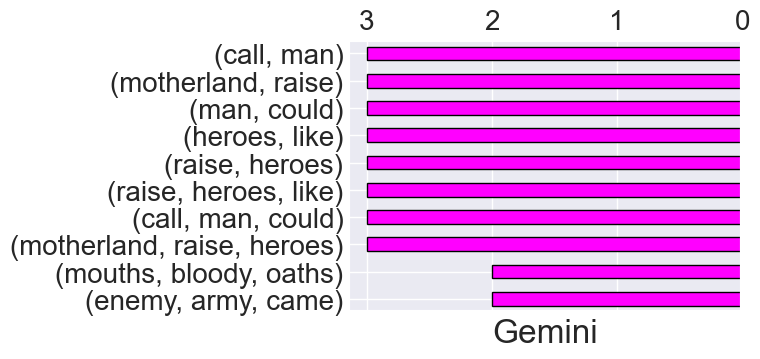

In [293]:
from matplotlib.ticker import MaxNLocator
bigram1 = ngrams_series_func(text, 2)
trigram1 = ngrams_series_func(text, 3)
ngram1 = pd.concat([bigram1, trigram1])

plt.rcParams.update({'font.size': 20})
fig, ax=plt.subplots(1,1, figsize=(8,4))

barh_ax = ax

ngram1[::-1].plot.barh(ax=barh_ax, color='magenta', **barstyle)
barh_ax.yaxis.set_label_position("left")
barh_ax.xaxis.tick_top()
barh_ax.xaxis.set_label_position("bottom")
barh_ax.set_xlim(barh_ax.get_xlim()[::-1])
barh_ax.xaxis.set_major_locator(MaxNLocator(integer=True))
barh_ax.set_xlabel('Gemini')
barh_ax.set_ylabel('', fontsize=50)
plt.tight_layout()
plt.savefig('Code_new/results/poems/graphs/ngrams/gemini.png', facecolor='white')